# PBI Database Exploration and Quality Control

This notebook serves as a comprehensive guide for exploring the PBI (Phage-Bacteria Interaction) database, understanding data quality, and visualizing database composition.

## What You'll Learn
1. **Database Connection** - Connect to PBI using `quick_connect()` and explore its structure
2. **Database Statistics** - Overview of phage, host, and association counts
3. **Source Database Distribution** - Which databases contribute phages
4. **Host Genome Coverage** - Hosts mentioned in phage records vs. hosts with downloadable genomes
5. **Phage Quality** - Completeness, lifestyle, genome length, and GC content distributions
6. **Host Taxonomy** - Host species diversity and assembly quality
7. **Phage-Host Pairs** - Properties of known phage-host interactions
8. **Understanding Warnings** - How to interpret missing sequence warnings

## About PBI
PBI aggregates phage-host interaction data from 26 public databases (RefSeq, Genbank, PhagesDB, GPD, GVD, MGV, and more) into a unified DuckDB database with associated FASTA sequence files. Not every phage has a sequenced host genome, and not every host has a downloadable genome — this is **expected and normal**.

## Setup & Imports

We import standard data science libraries plus the `pbi` package. The `sys.path.insert` ensures the package is found when running from the notebooks directory.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pbi
from pbi import quick_connect

# Visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Packages imported successfully")

import os

results_root = Path(os.getenv('PBI_RESULTS_DIR', '/results'))
try:
    results_root.mkdir(parents=True, exist_ok=True)
except Exception:
    results_root = project_root / 'outputs'
    results_root.mkdir(parents=True, exist_ok=True)

NOTEBOOK_RESULTS_DIR = results_root / '01_database_exploration'
TABLES_DIR = NOTEBOOK_RESULTS_DIR / 'tables'
FIGURES_DIR = NOTEBOOK_RESULTS_DIR / 'figures'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Notebook results directory: {NOTEBOOK_RESULTS_DIR}")


Packages imported successfully
Notebook results directory: /results/01_database_exploration


## Database Connection

`pbi.quick_connect()` auto-detects the database path and all FASTA files. It returns a `SequenceRetriever` object that provides:
- **Metadata queries** via DuckDB (fast SQL access)
- **Sequence retrieval** via indexed FASTA files (pyfaidx random access)
- **Dataset creation** for ML workflows

The connection takes time as it has to load all phages and protein. The "quick" in quick_connect() is clearly marketing. In reality, it might takes five to ten minutes to load !


In [2]:
# Connect to the database
retriever = quick_connect()
print("Connected to database")

# Get database statistics
stats = retriever.get_stats()
print("\n Database Statistics:")
for category, values in stats.items():
    print(f"\n{category.upper()}:")
    for key, value in values.items():
        if isinstance(value, (int, float)):
            print(f"  {key}: {value:,}")
        else:
            print(f"  {key}: {value}")

2026-07-05 09:10:49,211 - INFO - 📂 Checking FASTA index files:
2026-07-05 09:10:49,212 - INFO -    Phage index: True (82826.5 KB)
2026-07-05 09:10:49,217 - INFO -    Protein index: True (4376442.2 KB)
2026-07-05 09:10:49,220 - INFO - 📂 Loaded private phage mapping for 2 sources: ['test_private', 'test_private_2']
2026-07-05 09:10:49,221 - INFO - 📂 Using host mapping file: /data/processed/sequences/host_fasta_mapping.json
2026-07-05 09:10:49,228 - INFO -    Loaded mapping for 5517 hosts
2026-07-05 09:10:49,229 - INFO - 📂 Connecting to database: /data/processed/databases/phage_database_optimized.duckdb
2026-07-05 09:10:49,266 - INFO - 🔄 Starting background FASTA loading...
2026-07-05 09:10:49,267 - INFO - 🔄 [Background] Loading phage FASTA: /data/processed/sequences/all_phages.fasta
2026-07-05 09:10:49,267 - INFO - ✅ Initialization complete (FASTA loading in background)
2026-07-05 09:10:49,270 - INFO - ⏳ Waiting for FASTA loading to complete...


Connected to database


2026-07-05 09:11:01,936 - INFO -    ✅ Phage FASTA loaded in 12.67s (1,327,915 sequences)
2026-07-05 09:11:01,938 - INFO - 🔄 [Background] Loading protein FASTA: /data/processed/sequences/all_proteins.fasta
2026-07-05 09:15:49,273 - WARNING - ⚠️ Timeout after 300s - FASTA may still be loading
2026-07-05 09:27:07,843 - INFO -    ✅ Protein FASTA loaded in 965.90s (71,969,191 sequences)
2026-07-05 09:27:07,846 - INFO -    ℹ️  Using on-demand loading for 5,517 individual host files
2026-07-05 09:27:07,847 - INFO - 🎉 All FASTA files loaded in 978.58s
2026-07-05 09:27:29,997 - INFO - 🔍 Sample phage keys:
2026-07-05 09:27:29,998 - INFO -    - 'AE002163.1...'
2026-07-05 09:27:29,999 - INFO -    - 'AF009630.1...'
2026-07-05 09:27:30,000 - INFO -    - 'AF011378.1...'
2026-07-05 09:27:30,001 - INFO - 🔍 Sample protein keys:
2026-07-05 09:27:30,002 - INFO -    - 'AE002163.1 AAF39720.1...'
2026-07-05 09:27:30,003 - INFO -    - 'AE002163.1 AAF39721.1...'
2026-07-05 09:27:30,004 - INFO -    - 'AE002163.


 Database Statistics:

DATABASE:
  phages: 1,350,644
  proteins: 71,971,209
  hosts: 5,529
  phage_host_associations: 1,241,301
  source_breakdown: [{'source_type': 'private', 'Source_DB': 'test_private', 'count': 5}, {'source_type': 'private', 'Source_DB': 'test_private_2', 'count': 3}, {'source_type': 'public', 'Source_DB': 'MetaVR', 'count': 225269}, {'source_type': 'public', 'Source_DB': 'GOV2', 'count': 195699}, {'source_type': 'public', 'Source_DB': 'MGV', 'count': 189680}, {'source_type': 'public', 'Source_DB': 'IMGVR', 'count': 177361}, {'source_type': 'public', 'Source_DB': 'GPD', 'count': 142809}, {'source_type': 'public', 'Source_DB': 'TemPhD', 'count': 66823}, {'source_type': 'public', 'Source_DB': 'ELGV', 'count': 56716}, {'source_type': 'public', 'Source_DB': 'CHVD', 'count': 44935}, {'source_type': 'public', 'Source_DB': 'URPC', 'count': 44633}, {'source_type': 'public', 'Source_DB': 'TYMEFLIES', 'count': 44192}, {'source_type': 'public', 'Source_DB': 'OVD', 'count': 37

## Database Statistics Overview

The statistics above show:
- **database.phages**: Total phage records in the database
- **database.hosts**: Host bacterial genomes with metadata
- **database.phage_host_associations**: Known phage-host infection pairs
- **fasta.phages / fasta.proteins**: Sequences available in FASTA files

Note: `fasta.phages` may differ from `database.phages` — not all phages have a downloaded sequence file.

## 1. Phage Entries per Source Database

The PBI database aggregates phages from multiple sources. Understanding the source distribution helps identify which databases contribute most data and assess potential biases.

**Common sources include:**
- **RefSeq/Genbank**: Curated phage genomes from NCBI
- **PhagesDB**: Primarily *Mycobacterium* phages from SEA-PHAGES program
- **GPD/GVD/MGV**: Large metagenomic viral datasets
- **IMG/VR**: Metagenomic viral sequences

2026-07-05 09:27:34,492 - INFO - 🔍 Querying phage metadata...
2026-07-05 09:27:36,782 - INFO - ✅ Retrieved metadata for 1,350,644 phages



 Phage Entries per Source Database:
Source Database  Count  Percentage
         MetaVR 225269       16.68
           GOV2 195699       14.49
            MGV 189680       14.04
          IMGVR 177361       13.13
            GPD 142809       10.57
         TemPhD  66823        4.95
           ELGV  56716        4.20
           CHVD  44935        3.33
           URPC  44633        3.30
      TYMEFLIES  44192        3.27
            OVD  37184        2.75
            GVD  31402        2.32
           UHGV  21176        1.57
           BAPS  18590        1.38
            OPD  14649        1.08
           IGVD  10021        0.74
         RefSeq   4637        0.34
            GSV   4518        0.33
            STV   4065        0.30
           HPGC   3872        0.29
       PhagesDB   3754        0.28
           VMGC   3485        0.26
            SVD   2634        0.20
        Genbank   2086        0.15
           DDBJ    290        0.02
           EMBL    156        0.01
   test_private   

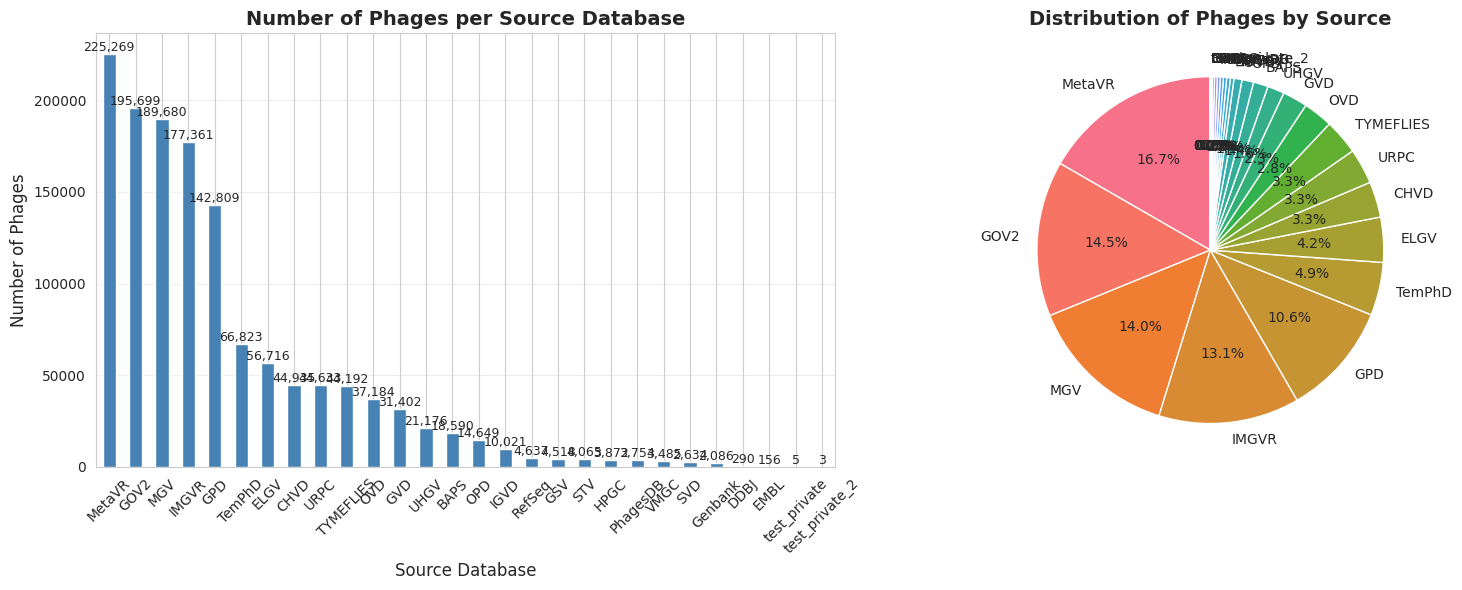

In [3]:
# Get phage metadata
phage_metadata = retriever.get_phage_metadata()

# Count entries per source
source_counts = phage_metadata['Source_DB'].value_counts().sort_values(ascending=False)

print("\n Phage Entries per Source Database:")
print("="*50)
source_df = pd.DataFrame({
    'Source Database': source_counts.index,
    'Count': source_counts.values,
    'Percentage': (source_counts.values / source_counts.sum() * 100).round(2)
})
print(source_df.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

source_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Number of Phages per Source Database', fontsize=14, fontweight='bold')
ax1.set_xlabel('Source Database', fontsize=12)
ax1.set_ylabel('Number of Phages', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(source_counts.values):
    ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

colors = sns.color_palette('husl', len(source_counts))
ax2.pie(source_counts.values, labels=source_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors)
ax2.set_title('Distribution of Phages by Source', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Private Data Sources (dynamic discovery)

Private-source names come from the `Source_DB` values that were actually ingested into `fact_phages`.
Because source folders can change (for example `test_private` vs `test_private_2`), this section first lists available private sources, then explores one selected source.

If no private source appears, check private-source validation (`private_manifest.json`) and rerun ingestion.


In [4]:
# ── Discover available private sources first ─────────────────────────────────
source_summary = retriever.conn.execute("""
    SELECT
        Source_DB,
        CASE
            WHEN LOWER(TRIM(COALESCE(source_type, ''))) = 'private' THEN 'private'
            ELSE 'public'
        END AS source_type,
        COUNT(*) AS phage_count
    FROM fact_phages
    GROUP BY Source_DB, source_type
    ORDER BY source_type, Source_DB
""").fetchdf()

print('Source summary from fact_phages:')
display(source_summary)

private_sources = sorted(
    source_summary.loc[source_summary['source_type'] == 'private', 'Source_DB']
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

if not private_sources:
    print('⚠️  No private sources are currently visible in fact_phages.')
    print('   Check private_data/private_manifest.json (or /private-data/private_manifest.json in container).')
else:
    selected_private_source = 'test_private' if 'test_private' in private_sources else private_sources[0]
    print(f'Private sources detected: {private_sources}')
    print(f'Using source for exploration: {selected_private_source}')

    private_phages = retriever.get_phage_metadata(
        where_clause=f"Source_DB = '{selected_private_source}'"
    )

    print(f"Private phages ({selected_private_source}): {len(private_phages)}")

    if len(private_phages) > 0:
        print('All private phage IDs:')
        print(private_phages['Phage_ID'].tolist())

        print('Lifestyle / interaction distribution:')
        lifestyle_col = 'Lifestyle' if 'Lifestyle' in private_phages.columns else 'interaction'
        if lifestyle_col in private_phages.columns:
            print(private_phages[lifestyle_col].value_counts(dropna=False))
        else:
            print('No lifestyle/interaction column found.')

        print('📋 Private phage metadata (non-empty columns):')
        preferred_cols = [
            'Phage_ID', 'Source_DB', 'Host', 'Lifestyle',
            'Length', 'GC_content', 'Taxonomy', 'Completeness', 'Cluster', 'Subcluster'
        ]
        existing_cols = [c for c in preferred_cols if c in private_phages.columns]
        private_display = private_phages[existing_cols].copy()
        key_cols = {'Phage_ID', 'Source_DB', 'Host', 'Lifestyle'}
        non_empty_cols = [c for c in private_display.columns if c in key_cols or private_display[c].notna().any()]
        private_display = private_display[non_empty_cols].fillna('N/A')
        display(private_display)

        # Optional columns from private metadata.csv are stored in private_entity_attributes
        try:
            attrs = retriever.conn.execute("""
                SELECT entity_id, attribute_key, attribute_value
                FROM private_entity_attributes
                WHERE Source_DB = ? AND entity_type = 'interaction'
            """, [selected_private_source]).fetchdf()

            if len(attrs) > 0:
                print('📋 Extra private attributes from metadata.csv:')
                attrs_wide = (
                    attrs.pivot_table(
                        index='entity_id',
                        columns='attribute_key',
                        values='attribute_value',
                        aggfunc='first'
                    )
                    .reset_index()
                )
                attrs_wide[['Phage_ID', 'Host_ID']] = attrs_wide['entity_id'].str.split('|', n=1, expand=True)
                attrs_wide = attrs_wide.drop(columns=['entity_id'])
                front_cols = ['Phage_ID', 'Host_ID']
                other_cols = [c for c in attrs_wide.columns if c not in front_cols]
                attrs_wide = attrs_wide[front_cols + other_cols]
                display(attrs_wide)
        except Exception as e:
            print(f"Note: could not query private_entity_attributes ({e})")

    # ── Filter phage-host pairs for selected private source ─────────────────
    try:
        private_pairs = retriever.get_phage_host_metadata(
            where_clause=f"p.Source_DB = '{selected_private_source}'"
        )
        print(f"Private phage-host pairs ({selected_private_source}): {len(private_pairs)}")
        if len(private_pairs) > 0:
            cols = [c for c in ['Phage_ID', 'Host_ID', 'Host_Species', 'Host_name', 'Interaction_Type']
                    if c in private_pairs.columns]
            display(private_pairs[cols].head(10))
    except Exception as e:
        print(f"Note: {e}")


Source summary from fact_phages:


,Source_DB,source_type,phage_count
0,test_private,private,5
1,test_private_2,private,3
2,BAPS,public,18590
3,CHVD,public,44935
4,DDBJ,public,290
5,ELGV,public,56716
6,EMBL,public,156
7,GOV2,public,195699
8,GPD,public,142809
9,GSV,public,4518


2026-07-05 09:27:41,935 - INFO - 🔍 Querying phage metadata...
2026-07-05 09:27:41,942 - INFO - ✅ Retrieved metadata for 5 phages


Private sources detected: ['test_private', 'test_private_2']
Using source for exploration: test_private
Private phages (test_private): 5
All private phage IDs:
['TEST_PHAGE_ALPHA', 'TEST_PHAGE_BETA', 'TEST_PHAGE_GAMMA', 'TEST_PHAGE_DELTA', 'TEST_PHAGE_EPSILON']
Lifestyle / interaction distribution:
Lifestyle
virulent     3
temperate    2
Name: count, dtype: int64
📋 Private phage metadata (non-empty columns):


,Phage_ID,Source_DB,Host,Lifestyle
0,TEST_PHAGE_ALPHA,test_private,Escherichia coli K-12,virulent
1,TEST_PHAGE_BETA,test_private,Escherichia coli K-12,temperate
2,TEST_PHAGE_GAMMA,test_private,Bacillus subtilis 168,virulent
3,TEST_PHAGE_DELTA,test_private,Bacillus subtilis 168,temperate
4,TEST_PHAGE_EPSILON,test_private,Pseudomonas aeruginosa PA01,virulent


📋 Extra private attributes from metadata.csv:


attribute_key,Phage_ID,Host_ID,Description,Year_Isolated
0,TEST_PHAGE_ALPHA,TEST_HOST_ECOLI_A,Test lytic phage infecting E. coli,2024
1,TEST_PHAGE_BETA,TEST_HOST_ECOLI_A,Test lysogenic phage infecting E. coli,2024
2,TEST_PHAGE_DELTA,TEST_HOST_BSUBT_B,Test lysogenic phage infecting B. subtilis,2024
3,TEST_PHAGE_EPSILON,TEST_HOST_PAERUG_C,Test lytic phage infecting P. aeruginosa,2024
4,TEST_PHAGE_GAMMA,TEST_HOST_BSUBT_B,Test lytic phage infecting B. subtilis,2024


2026-07-05 09:27:41,974 - INFO - 🔍 Querying phage-host metadata...
2026-07-05 09:27:42,245 - INFO - ✅ Retrieved metadata for 5 phage-host pairs


Private phage-host pairs (test_private): 5


,Phage_ID,Host_ID,Host_Species
0,TEST_PHAGE_GAMMA,TEST_HOST_BSUBT_B,Bacillus subtilis 168
1,TEST_PHAGE_DELTA,TEST_HOST_BSUBT_B,Bacillus subtilis 168
2,TEST_PHAGE_EPSILON,TEST_HOST_PAERUG_C,Pseudomonas aeruginosa PA01
3,TEST_PHAGE_BETA,TEST_HOST_ECOLI_A,Escherichia coli K-12
4,TEST_PHAGE_ALPHA,TEST_HOST_ECOLI_A,Escherichia coli K-12


## Public provenance and version pinning checks

The pipeline stores provider pinning and download provenance in two DuckDB tables when available:
- `pipeline_run_provenance` (run-level pinning metadata)
- `dataset_provenance` (per-source download/provenance records)


In [5]:
tables_df = retriever.conn.execute("SHOW TABLES").fetchdf()
available_tables = set(tables_df.iloc[:, 0].astype(str).tolist())

if 'pipeline_run_provenance' in available_tables:
    print('pipeline_run_provenance:')
    run_prov = retriever.conn.execute("""
        SELECT *
        FROM pipeline_run_provenance
        ORDER BY pipeline_run_timestamp DESC
        LIMIT 5
    """).fetchdf()
    display(run_prov)
else:
    print('pipeline_run_provenance table not found in this database.')

if 'dataset_provenance' in available_tables:
    print('dataset_provenance status summary:')
    status_df = retriever.conn.execute("""
        SELECT status, COUNT(*) AS rows
        FROM dataset_provenance
        GROUP BY status
        ORDER BY status
    """).fetchdf()
    display(status_df)

    failed_df = retriever.conn.execute("""
        SELECT feature, source_key, source_url, status, error_message
        FROM dataset_provenance
        WHERE COALESCE(status, '') <> 'success'
        ORDER BY feature, source_key
        LIMIT 20
    """).fetchdf()
    if len(failed_df) > 0:
        print('⚠️ Non-success provenance rows:')
        display(failed_df)
else:
    print('dataset_provenance table not found in this database.')


pipeline_run_provenance:


,pipeline_run_timestamp,provider_name,provider_release,provider_snapshot_date,provider_schema_profile,provider_api_base_url,provider_provenance_mode,pbi_version,git_commit,download_records_count
0,2026-07-04T15:56:50Z,PhageScope,rolling,2026-05-11,phagescope_v1,https://phageapi.deepomics.org,config_pinned,None,None,229


dataset_provenance status summary:


,status,rows
0,failed,13
1,success,216


⚠️ Non-success provenance rows:


,feature,source_key,source_url,status,error_message
0,antimicrobial_resistance_gene_metadata,TYMEFLIES_Antimicrobial_Resistance_Gene_Metada...,https://phageapi.deepomics.org/files/Download/...,failed,HTTP Error 500: Internal Server Error
1,phage_anti_crispr_metadata,TemPhD_Phage_AntiCRISPR_Metadata_URL,https://phageapi.deepomics.org/files/Download/...,failed,HTTP Error 500: Internal Server Error
2,phage_transmembrane_protein_metadata,BAPS_Phage_Transmembrane_Protein_Metadata_URL,https://phageapi.deepomics.org/files/Download/...,failed,HTTP Error 500: Internal Server Error
3,phage_transmembrane_protein_metadata,ELGV_Phage_Transmembrane_Protein_Metadata_URL,https://phageapi.deepomics.org/files/Download/...,failed,HTTP Error 500: Internal Server Error
4,phage_transmembrane_protein_metadata,MetaVR_Phage_Transmembrane_Protein_Metadata_URL,https://phageapi.deepomics.org/files/Download/...,failed,HTTP Error 500: Internal Server Error
5,phage_transmembrane_protein_metadata,OPD_Phage_Transmembrane_Protein_Metadata_URL,https://phageapi.deepomics.org/files/Download/...,failed,HTTP Error 500: Internal Server Error
6,phage_transmembrane_protein_metadata,OVD_Phage_Transmembrane_Protein_Metadata_URL,https://phageapi.deepomics.org/files/Download/...,failed,HTTP Error 500: Internal Server Error
7,phage_transmembrane_protein_metadata,SVD_Phage_Transmembrane_Protein_Metadata_URL,https://phageapi.deepomics.org/files/Download/...,failed,HTTP Error 500: Internal Server Error
8,phage_transmembrane_protein_metadata,TYMEFLIES_Phage_Transmembrane_Protein_Metadata...,https://phageapi.deepomics.org/files/Download/...,failed,HTTP Error 500: Internal Server Error
9,phage_transmembrane_protein_metadata,VMGC_Phage_Transmembrane_Protein_Metadata_URL,https://phageapi.deepomics.org/files/Download/...,failed,HTTP Error 500: Internal Server Error


## 2. Hosts in Phage Table vs. Available Host Genomes

This section answers a key question: **how many phages have a sequenced host genome available?**

The phage table records the host organism (e.g., "Escherichia coli"), but a downloadable host genome requires:
1. The host species being in NCBI/RefSeq with a genome assembly
2. The genome being downloaded as part of the PBI pipeline

**Expected behavior:** Many phages will *not* have a host genome available. This is normal — some hosts are unsequenced, some assemblies are unavailable, and some hosts may be recorded at a genus level without a matching genome.

2026-07-05 09:27:42,563 - INFO - 🔍 Querying host metadata...
2026-07-05 09:27:42,577 - INFO - ✅ Retrieved metadata for 5,529 hosts
2026-07-05 09:27:42,579 - INFO - 🔍 Querying phage-host metadata...
2026-07-05 09:27:47,479 - INFO - ✅ Retrieved metadata for 1,274,998 phage-host pairs



 Host Genome Coverage Analysis:
Unique hosts mentioned in phage table: 13,806
Hosts with available genomes: 5,402
Phage-host associations: 1,274,998
Unique phages in associations: 1,218,991
Unique hosts in associations: 5,529


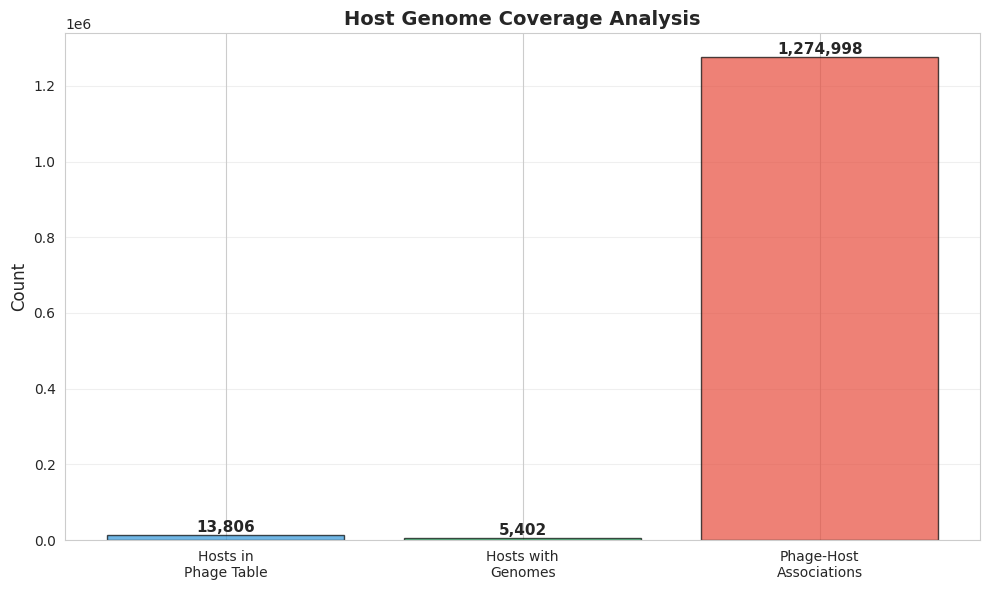

In [6]:
# Get unique hosts mentioned in phage table
hosts_in_phage_table = phage_metadata['Host'].dropna().unique()

# Get hosts with available genomes
try:
    host_metadata = retriever.get_host_metadata()
    hosts_with_genomes = host_metadata['Species_Name'].unique()

    # Get phage-host associations
    phage_host_pairs = retriever.get_phage_host_metadata()

    print("\n Host Genome Coverage Analysis:")
    print("="*50)
    print(f"Unique hosts mentioned in phage table: {len(hosts_in_phage_table):,}")
    print(f"Hosts with available genomes: {len(hosts_with_genomes):,}")
    print(f"Phage-host associations: {len(phage_host_pairs):,}")
    print(f"Unique phages in associations: {phage_host_pairs['Phage_ID'].nunique():,}")
    print(f"Unique hosts in associations: {phage_host_pairs['Host_ID'].nunique():,}")

    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    categories = ['Hosts in\nPhage Table', 'Hosts with\nGenomes', 'Phage-Host\nAssociations']
    values = [len(hosts_in_phage_table), len(hosts_with_genomes), len(phage_host_pairs)]
    colors = ['#3498db', '#2ecc71', '#e74c3c']

    bars = ax.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Host Genome Coverage Analysis', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Host genome data not available: {e}")
    print("   Run the host genome download workflow first.")

## 3. Phage Quality (Completeness) Distribution

Phage genome completeness indicates how much of the phage genome was sequenced and assembled. This is critical for reliable analysis:

- **Complete**: Full genome sequence, suitable for most analyses
- **High-quality draft**: Nearly complete, reliable for most purposes
- **Medium/Low quality**: Fragmented or partial — use with caution
- **Not determined**: Quality not assessed

For machine learning, filtering to complete or high-quality genomes is recommended.


 Phage Completeness Distribution:
  Completeness  Count  Percentage
  High-quality 533244       39.48
   Low-quality 334344       24.75
Medium-quality 291096       21.55
      Complete 169857       12.58
Not-determined  22095        1.64


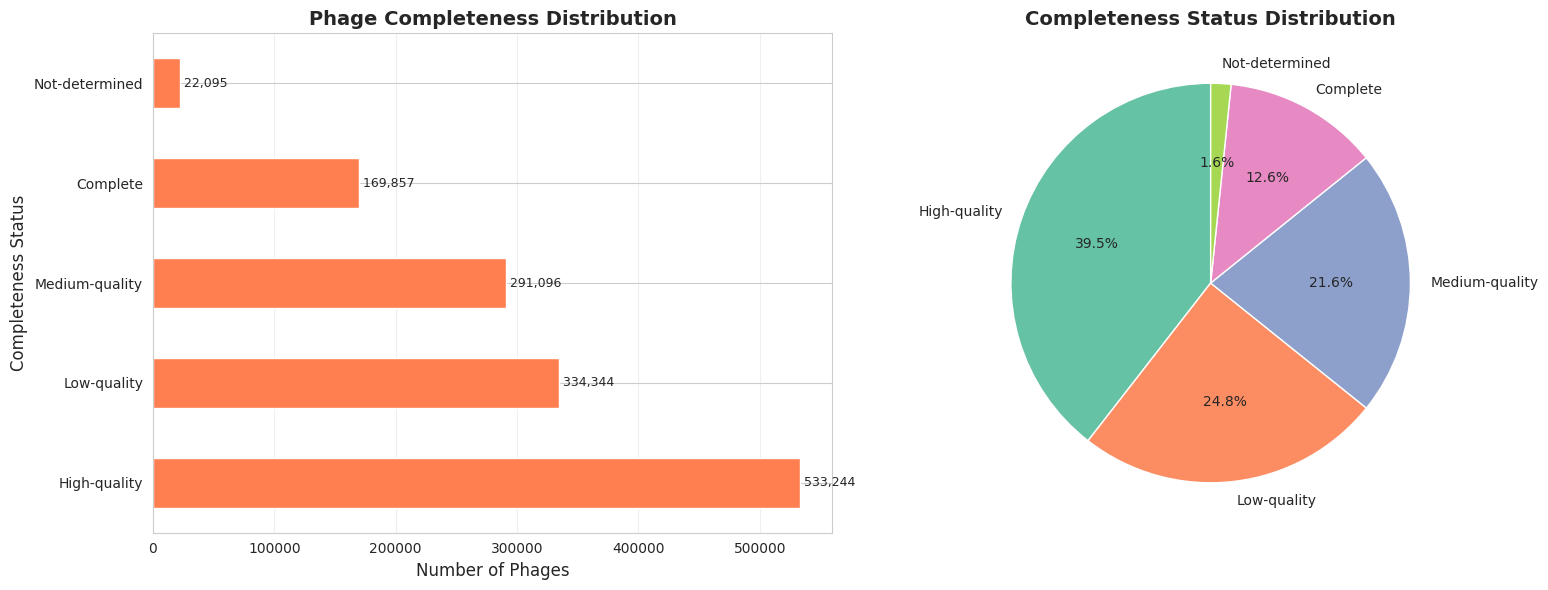

In [7]:
# Analyze completeness distribution
completeness_counts = phage_metadata['Completeness'].value_counts().sort_values(ascending=False)

print("\n Phage Completeness Distribution:")
print("="*50)
completeness_df = pd.DataFrame({
    'Completeness': completeness_counts.index,
    'Count': completeness_counts.values,
    'Percentage': (completeness_counts.values / completeness_counts.sum() * 100).round(2)
})
print(completeness_df.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

completeness_counts.plot(kind='barh', ax=ax1, color='coral')
ax1.set_title('Phage Completeness Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Phages', fontsize=12)
ax1.set_ylabel('Completeness Status', fontsize=12)
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(completeness_counts.values):
    ax1.text(v, i, f' {v:,}', va='center', fontsize=9)

colors = sns.color_palette('Set2', len(completeness_counts))
ax2.pie(completeness_counts.values, labels=completeness_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors)
ax2.set_title('Completeness Status Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Phage Lifestyle Distribution

Phage lifestyle describes how a phage interacts with its host:

- **Lytic (virulent)**: The phage always kills the host cell immediately after replication
- **Lysogenic (temperate)**: The phage integrates into the host genome and may remain dormant
- **Unknown/Chronic**: Other lifestyles including chronic infection

Lifestyle is important for therapeutic applications — lytic phages are preferred for phage therapy as they reliably kill bacteria.


 Phage Lifestyle Distribution:
Lifestyle  Count  Percentage
 virulent 843901       62.48
temperate 500480       37.05
        -   5807        0.43
 filtered    456        0.03


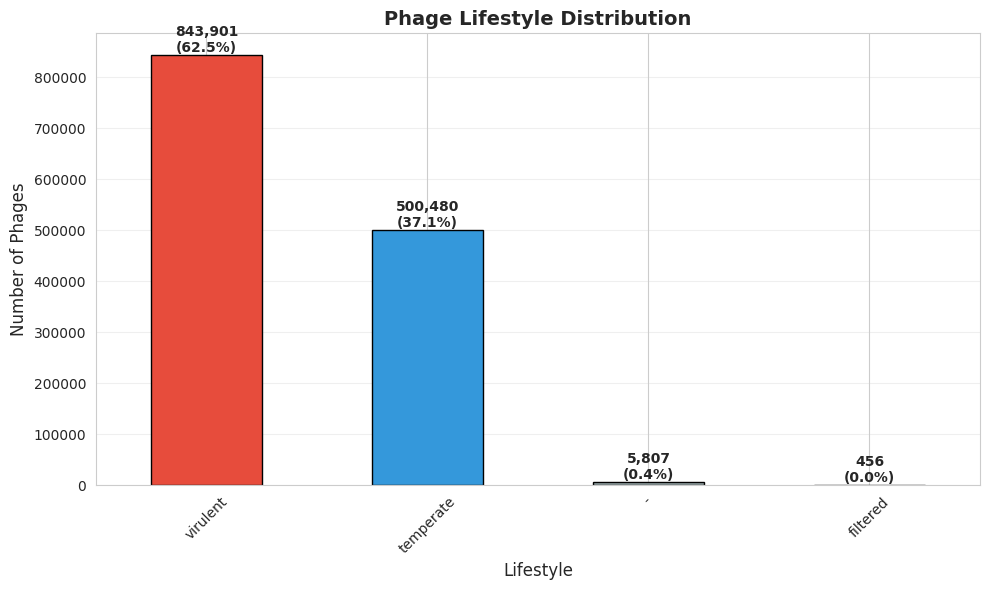

In [8]:
# Analyze lifestyle distribution
lifestyle_counts = phage_metadata['Lifestyle'].value_counts()

print("\n Phage Lifestyle Distribution:")
print("="*50)
lifestyle_df = pd.DataFrame({
    'Lifestyle': lifestyle_counts.index,
    'Count': lifestyle_counts.values,
    'Percentage': (lifestyle_counts.values / lifestyle_counts.sum() * 100).round(2)
})
print(lifestyle_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c', '#3498db', '#95a5a6']
lifestyle_counts.plot(kind='bar', ax=ax, color=colors[:len(lifestyle_counts)], edgecolor='black')
ax.set_title('Phage Lifestyle Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Lifestyle', fontsize=12)
ax.set_ylabel('Number of Phages', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(lifestyle_counts.values):
    ax.text(i, v, f'{v:,}\n({lifestyle_counts.values[i]/lifestyle_counts.sum()*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Phage Genome Length Distribution

Phage genome sizes vary enormously:
- **Small phages**: 3-10 kb (e.g., ssDNA phages like phiX174)
- **Medium phages**: 10-100 kb (most common dsDNA phages)
- **Large/jumbo phages**: >100 kb (e.g., some T4-like phages can reach ~500 kb)

The distribution shape tells us about database composition. A right-skewed distribution is typical.


 Phage Genome Length Statistics:
Mean length: 39,746 bp
Median length: 35,571 bp
Min length: 203 bp
Max length: 1,359,420 bp
Std deviation: 34,670 bp


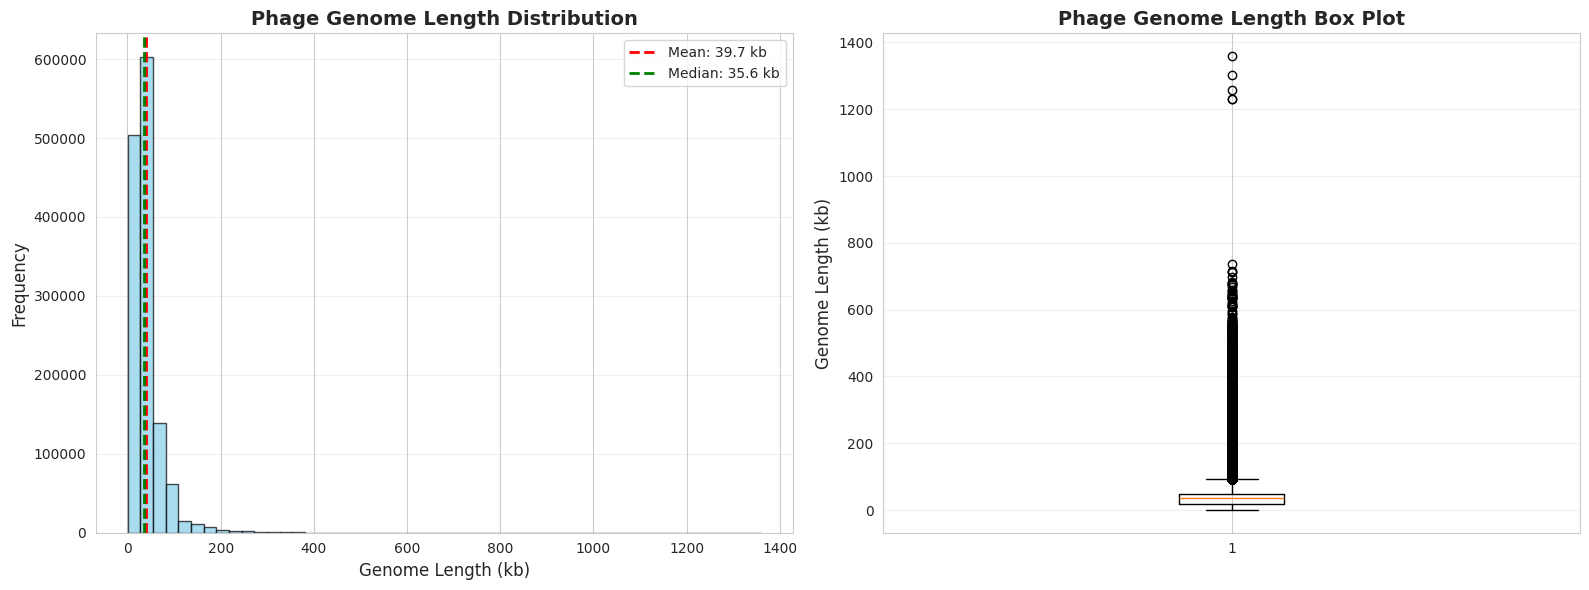

In [9]:
# Analyze genome length distribution
lengths = phage_metadata['Length'].dropna()

print("\n Phage Genome Length Statistics:")
print("="*50)
print(f"Mean length: {lengths.mean():,.0f} bp")
print(f"Median length: {lengths.median():,.0f} bp")
print(f"Min length: {lengths.min():,.0f} bp")
print(f"Max length: {lengths.max():,.0f} bp")
print(f"Std deviation: {lengths.std():,.0f} bp")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.hist(lengths/1000, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(lengths.mean()/1000, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {lengths.mean()/1000:.1f} kb')
ax1.axvline(lengths.median()/1000, color='green', linestyle='--', linewidth=2,
            label=f'Median: {lengths.median()/1000:.1f} kb')
ax1.set_xlabel('Genome Length (kb)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Phage Genome Length Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

ax2.boxplot(lengths/1000, vert=True)
ax2.set_ylabel('Genome Length (kb)', fontsize=12)
ax2.set_title('Phage Genome Length Box Plot', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. GC Content Analysis

GC content (percentage of guanine + cytosine bases) is a fundamental genomic property:

- **Phage GC content** reflects their evolutionary origin and host adaptation
- **Host GC content** is a taxonomic signature — Firmicutes tend to be AT-rich (~30-40% GC), Actinobacteria tend to be GC-rich (~60-75% GC)
- A correlation between phage and host GC content suggests co-evolution

The GC content difference between phage and host is a useful feature for host-range prediction.


 Phage GC Content Statistics:
Mean GC%: 44.82%
Median GC%: 43.83%
Min GC%: 8.29%
Max GC%: 78.50%
Std deviation: 9.55%


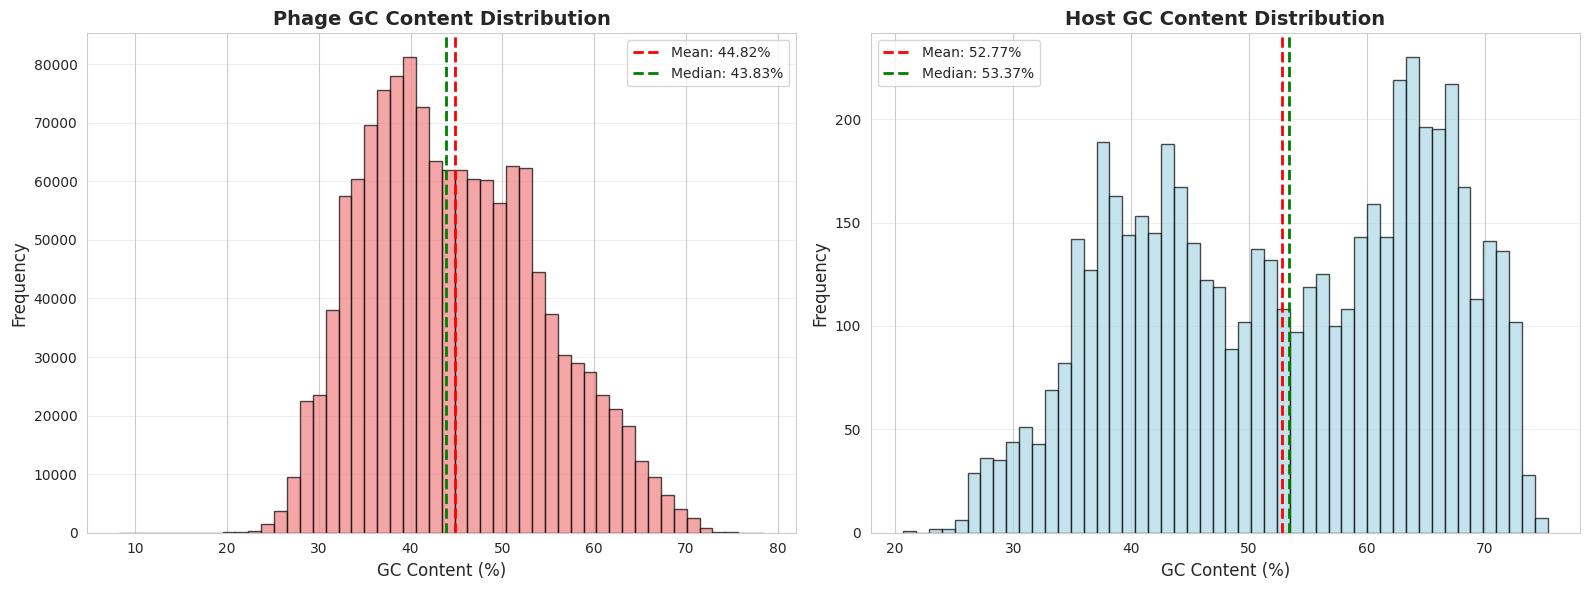

In [10]:
# Analyze GC content distribution
gc_content = phage_metadata['GC_content'].dropna()

print("\n Phage GC Content Statistics:")
print("="*50)
print(f"Mean GC%: {gc_content.mean():.2f}%")
print(f"Median GC%: {gc_content.median():.2f}%")
print(f"Min GC%: {gc_content.min():.2f}%")
print(f"Max GC%: {gc_content.max():.2f}%")
print(f"Std deviation: {gc_content.std():.2f}%")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.hist(gc_content, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax1.axvline(gc_content.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {gc_content.mean():.2f}%')
ax1.axvline(gc_content.median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {gc_content.median():.2f}%')
ax1.set_xlabel('GC Content (%)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Phage GC Content Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

try:
    host_gc = host_metadata['GC_Content'].dropna()
    ax2.hist(host_gc, bins=50, color='lightblue', edgecolor='black', alpha=0.7)
    ax2.axvline(host_gc.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {host_gc.mean():.2f}%')
    ax2.axvline(host_gc.median(), color='green', linestyle='--', linewidth=2,
                label=f'Median: {host_gc.median():.2f}%')
    ax2.set_xlabel('GC Content (%)', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Host GC Content Distribution', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
except Exception:
    ax2.text(0.5, 0.5, 'Host data not available',
             ha='center', va='center', transform=ax2.transAxes, fontsize=14)
    ax2.set_title('Host GC Content Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
phage_metadata = retriever.get_phage_metadata()
unique_raw_hosts = phage_metadata["Host"].unique()
print(f"There are {unique_raw_hosts.shape[0]} raw hosts.")

2026-07-05 09:27:51,235 - INFO - 🔍 Querying phage metadata...
2026-07-05 09:27:53,225 - INFO - ✅ Retrieved metadata for 1,350,644 phages


There are 13807 raw hosts.


In [12]:
pd.DataFrame(unique_raw_hosts).to_csv("/results/01_database_exploration/tables/unique_raw_hosts.csv")

In [13]:
os.listdir("/results/01_database_exploration/tables")

['source_df.parquet',
 'unique_raw_hosts.csv',
 'assembly_df.parquet',
 'private_pairs.parquet',
 'host_metadata.parquet',
 'phage_host_pairs.parquet',
 'phage_metadata.parquet',
 'completeness_df.parquet',
 'lifestyle_df.parquet']

# TODO: Raw Host Data analysis

## 7. Host Taxonomy Analysis

Understanding host diversity tells us about the range of bacteria that phages in this database infect. A database biased toward a few host genera (e.g., *Escherichia*, *Mycobacterium*) may produce biased ML models.

**Key metrics to check:**
- Number of distinct species
- Distribution of phages per host species
- Whether the most common hosts are well-represented biologically or just heavily studied (sampling bias)


 Top 20 Host Species:
 1. Escherichia coli                                      18
 2. Salmonella enterica                                   15
 3. uncultured Clostridium sp.                            11
 4. Prochlorococcus marinus                                7
 5. uncultured Blautia sp.                                 7
 6. uncultured Ruminococcus sp.                            5
 7. Bacillus thuringiensis                                 5
 8. uncultured Eubacterium sp.                             4
 9. Enterococcus faecalis                                  3
10. Vibrio cholerae                                        3
11. Staphylococcus aureus                                  3
12. Cronobacter malonaticus                                2
13. Bifidobacterium catenulatum                            2
14. Trichococcus flocculiformis                            2
15. Streptomyces griseus                                   2
16. Acinetobacter nosocomialis                             2
1

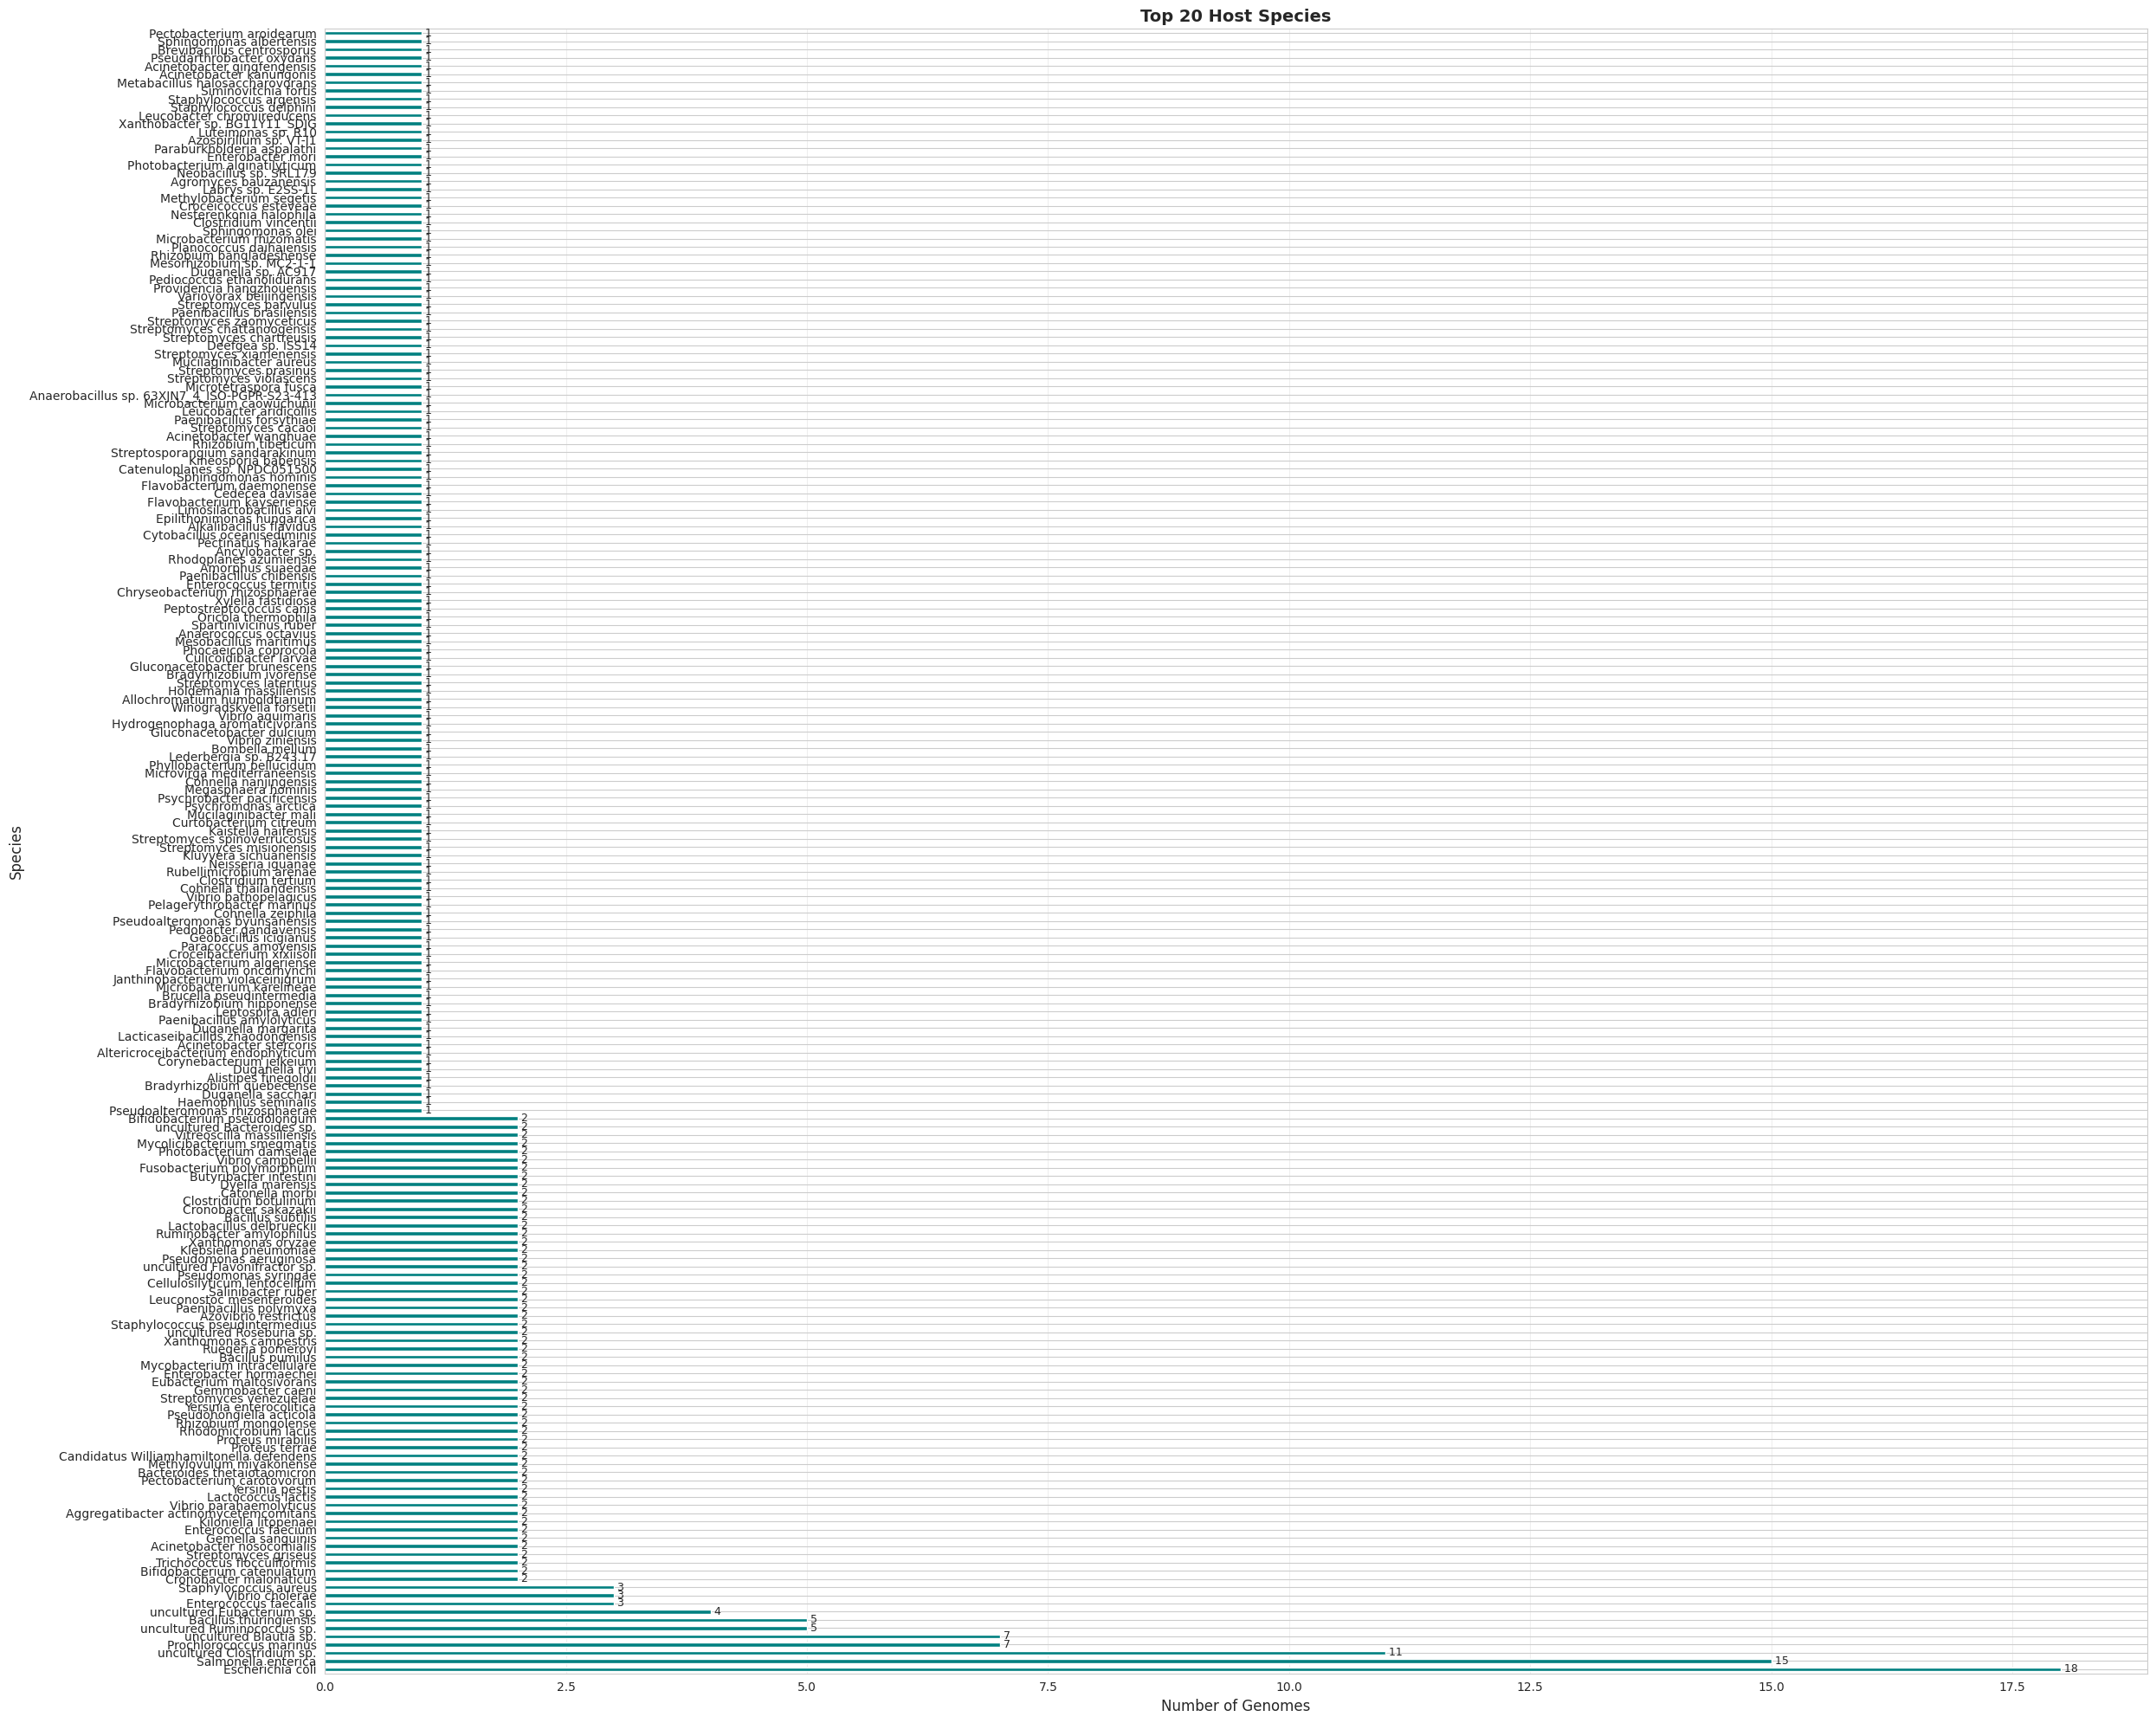

In [14]:
try:
    # Analyze host species distribution
    species_counts = host_metadata['Species_Name'].value_counts().head(200)

    print("\n Top 20 Host Species:")
    print("="*50)
    for i, (species, count) in enumerate(species_counts.items(), 1):
        print(f"{i:2d}. {species:50s} {count:5d}")

    # Visualize
    fig, ax = plt.subplots(figsize=(25, 20))
    species_counts.plot(kind='barh', ax=ax, color='teal')
    ax.set_title('Top 20 Host Species', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Genomes', fontsize=12)
    ax.set_ylabel('Species', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(species_counts.values):
        ax.text(v, i, f' {v}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Host taxonomy analysis not available: {e}")

## 8. Host Assembly Quality Distribution

NCBI assembly levels indicate genome completeness for host bacteria:
- **Complete Genome**: Fully assembled chromosome(s), highest quality
- **Chromosome**: Nearly complete with minor gaps
- **Scaffold**: Multiple contigs ordered but with gaps
- **Contig**: Unordered contigs, most fragmented

For sequence-based ML analyses, prefer **Complete Genome** or **Chromosome** assemblies for reliable results.


 Host Assembly Level Distribution:
 Assembly Level  Count  Percentage
Complete Genome   2196       39.75
       Scaffold   1767       31.99
         Contig   1454       26.32
     Chromosome    107        1.94


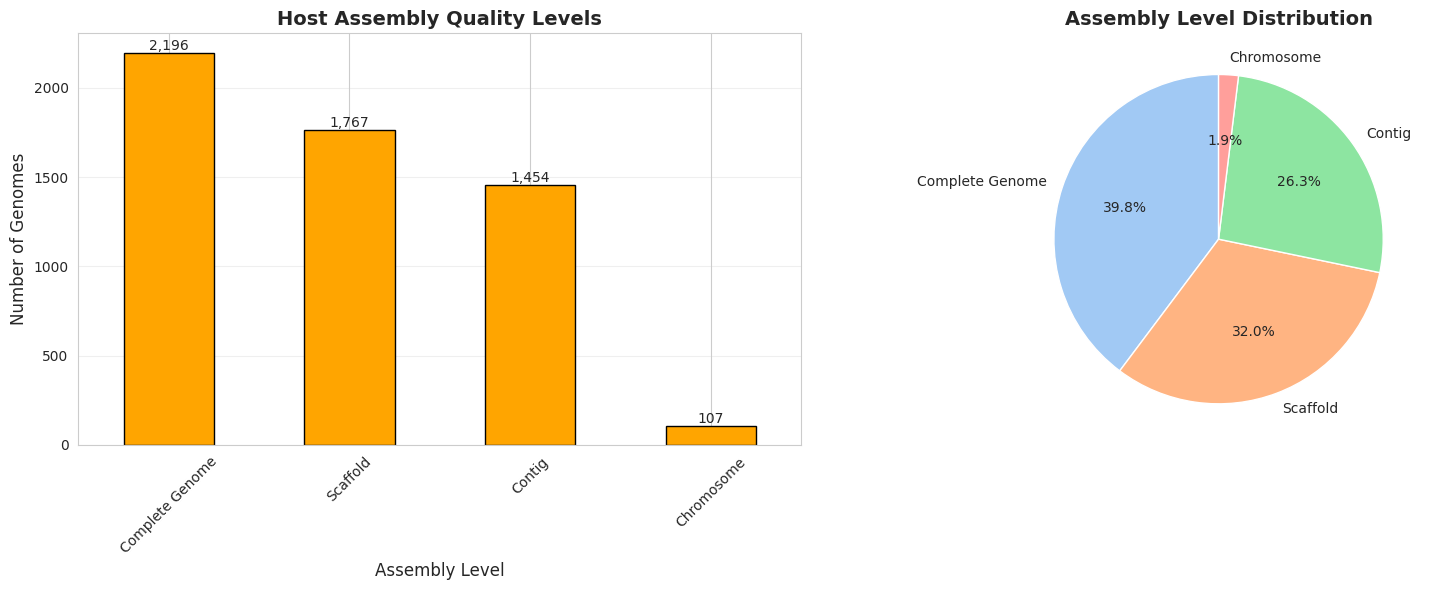

In [15]:
try:
    # Analyze assembly level distribution
    assembly_counts = host_metadata['Assembly_Level'].value_counts()

    print("\n Host Assembly Level Distribution:")
    print("="*50)
    assembly_df = pd.DataFrame({
        'Assembly Level': assembly_counts.index,
        'Count': assembly_counts.values,
        'Percentage': (assembly_counts.values / assembly_counts.sum() * 100).round(2)
    })
    print(assembly_df.to_string(index=False))

    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    assembly_counts.plot(kind='bar', ax=ax1, color='orange', edgecolor='black')
    ax1.set_title('Host Assembly Quality Levels', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Assembly Level', fontsize=12)
    ax1.set_ylabel('Number of Genomes', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    for i, v in enumerate(assembly_counts.values):
        ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)

    colors = sns.color_palette('pastel', len(assembly_counts))
    ax2.pie(assembly_counts.values, labels=assembly_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors)
    ax2.set_title('Assembly Level Distribution', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Assembly quality analysis not available: {e}")

## 9. Phage-Host Pair Analysis

Phage-host associations are the core of the database — these are ~~experimentally validated~~ infection pairs. Analyzing their properties helps understand:

- Which phage lifestyles are most studied in host-interaction contexts
- Which host assembly qualities are available for paired analyses
- Which host species are best represented with paired phage data

**Note:** Not every phage in the database has a paired host genome. Pairs here represent phages with *both* a metadata record AND a host with a genome sequence.


 Phage-Host Pair Statistics:

Phage Lifestyle in Pairs:
  virulent: 802,101 (62.9%)
  temperate: 466,486 (36.6%)
  -: 5,955 (0.5%)
  filtered: 456 (0.0%)

Top 10 Phage Sources in Pairs:
  MetaVR: 232,660
  GOV2: 193,311
  IMGVR: 159,191
  MGV: 155,886
  GPD: 141,711
  TemPhD: 64,911
  ELGV: 55,111
  TYMEFLIES: 44,031
  URPC: 42,930
  OVD: 36,771

Host Assembly Level in Pairs:
  Complete Genome: 1,087,457 (85.3%)
  Scaffold: 105,264 (8.3%)
  Contig: 64,678 (5.1%)
  Chromosome: 17,591 (1.4%)


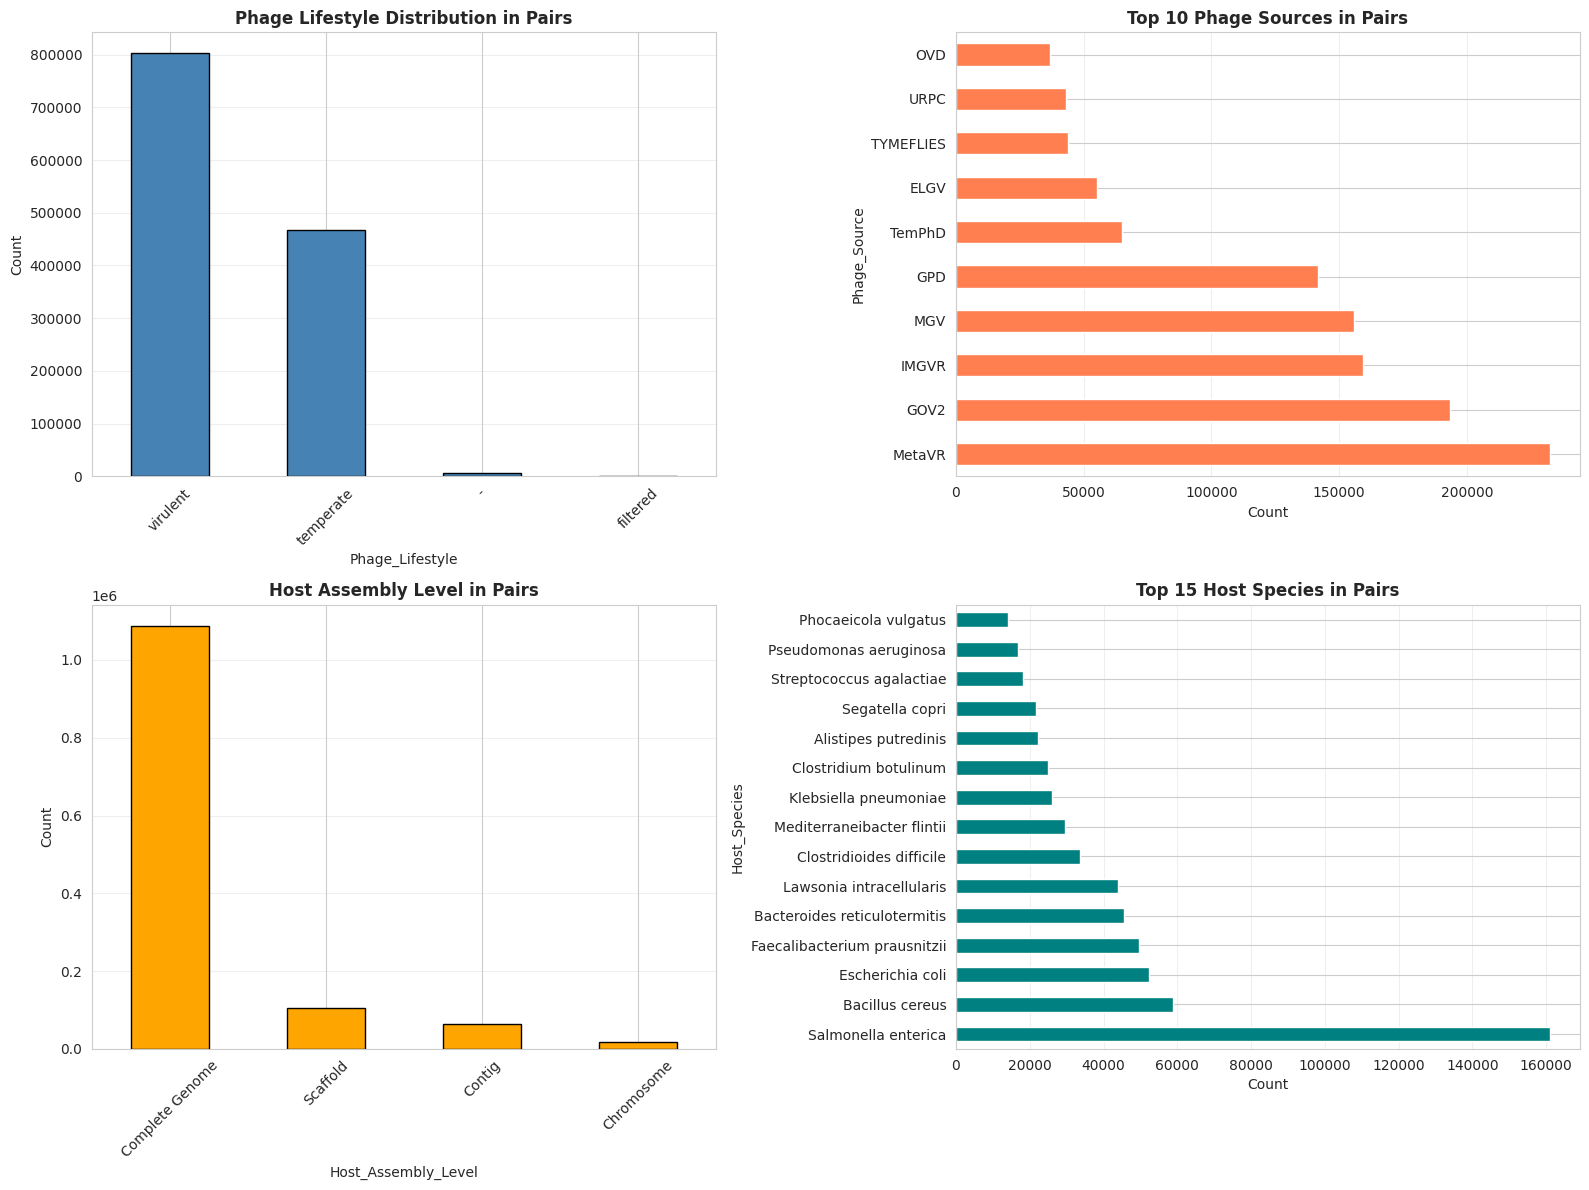

In [16]:
try:
    # Analyze phage-host metadata
    print("\n Phage-Host Pair Statistics:")
    print("="*50)

    # Lifestyle distribution in pairs
    pair_lifestyle = phage_host_pairs['Phage_Lifestyle'].value_counts()
    print("\nPhage Lifestyle in Pairs:")
    for lifestyle, count in pair_lifestyle.items():
        print(f"  {lifestyle}: {count:,} ({count/len(phage_host_pairs)*100:.1f}%)")

    # Source distribution in pairs
    pair_source = phage_host_pairs['Phage_Source'].value_counts().head(10)
    print("\nTop 10 Phage Sources in Pairs:")
    for source, count in pair_source.items():
        print(f"  {source}: {count:,}")

    # Assembly level distribution in pairs
    pair_assembly = phage_host_pairs['Host_Assembly_Level'].value_counts()
    print("\nHost Assembly Level in Pairs:")
    for level, count in pair_assembly.items():
        print(f"  {level}: {count:,} ({count/len(phage_host_pairs)*100:.1f}%)")

    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    pair_lifestyle.plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black')
    axes[0,0].set_title('Phage Lifestyle Distribution in Pairs', fontsize=12, fontweight='bold')
    axes[0,0].set_ylabel('Count', fontsize=10)
    axes[0,0].tick_params(axis='x', rotation=45)
    axes[0,0].grid(axis='y', alpha=0.3)

    pair_source.plot(kind='barh', ax=axes[0,1], color='coral')
    axes[0,1].set_title('Top 10 Phage Sources in Pairs', fontsize=12, fontweight='bold')
    axes[0,1].set_xlabel('Count', fontsize=10)
    axes[0,1].grid(axis='x', alpha=0.3)

    pair_assembly.plot(kind='bar', ax=axes[1,0], color='orange', edgecolor='black')
    axes[1,0].set_title('Host Assembly Level in Pairs', fontsize=12, fontweight='bold')
    axes[1,0].set_ylabel('Count', fontsize=10)
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,0].grid(axis='y', alpha=0.3)

    top_hosts = phage_host_pairs['Host_Species'].value_counts().head(15)
    top_hosts.plot(kind='barh', ax=axes[1,1], color='teal')
    axes[1,1].set_title('Top 15 Host Species in Pairs', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('Count', fontsize=10)
    axes[1,1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Phage-host pair analysis not available: {e}")

### Phages with Multiple Hosts (Broad Host Range)

Some phages infect more than one bacterial host species — a property known as **broad host range**.
This is biologically significant: broad-host-range phages are more versatile tools for phage therapy
and can provide insights into phage–host co-evolution.

**How it is managed in PBI:**  
The `phage_host_associations` table stores one row *per phage–host pair*, so a phage infecting *N* distinct hosts will appear in *N* rows, each with a different `Host_ID`.  
The `get_phage_host_metadata()` result therefore contains duplicate `Phage_ID` values whenever a phage has more than one host; counting those duplicates reveals the host-range distribution.

The cell below identifies the top broad-host-range phages and shows their full host list.


Total phages with host associations : 1,218,991
  Broad host range (>1 host)        : 17,335 (1.4%)
  Single host                       : 1,201,656 (98.6%)

Top 10 phages by number of distinct hosts:
--------------------------------------------------
  uvig_121821                              9 hosts: uncultured Clostridium sp., Agathobacter rectalis, Firmicutes bacterium CAG:227, Dorea formicigenerans, Roseburia inulinivorans … (+3 more)
  uvig_168507                              8 hosts: uncultured Clostridium sp., Lachnospira eligens, Clostridium sp. L2-50, Clostridium sp. CAG:43, Fusicatenibacter saccharivorans … (+3 more)
  uvig_228555                              8 hosts: Agathobacter rectalis, uncultured Blautia sp., Roseburia faecis, Roseburia sp. CAG:197, Fusicatenibacter saccharivorans … (+2 more)
  uvig_521530                              8 hosts: Lachnospira eligens, Roseburia intestinalis, uncultured Clostridium sp., Agathobacter rectalis, uncultured Blautia sp. … (+2 more

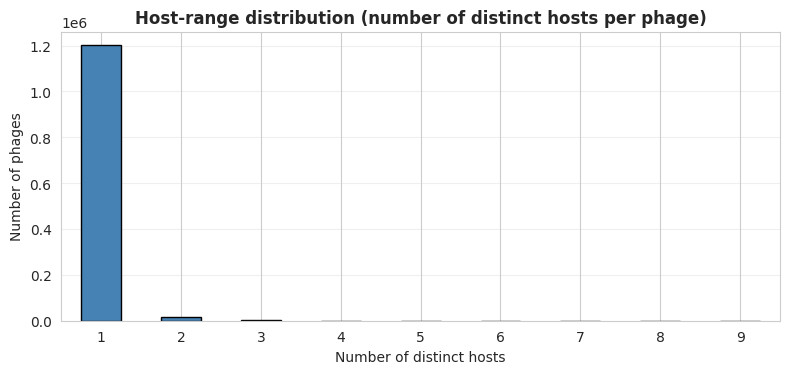

In [17]:
try:
    # Count distinct hosts per phage
    host_counts = (
        phage_host_pairs
        .groupby('Phage_ID')['Host_ID']
        .nunique()
        .reset_index()
        .rename(columns={'Host_ID': 'Host_Count'})
        .sort_values('Host_Count', ascending=False)
    )

    multi_host = host_counts[host_counts['Host_Count'] > 1]
    single_host = host_counts[host_counts['Host_Count'] == 1]

    print(f"Total phages with host associations : {len(host_counts):,}")
    print(f"  Broad host range (>1 host)        : {len(multi_host):,} "
          f"({len(multi_host)/len(host_counts)*100:.1f}%)")
    print(f"  Single host                       : {len(single_host):,} "
          f"({len(single_host)/len(host_counts)*100:.1f}%)")

    if not multi_host.empty:
        print(f"\nTop 10 phages by number of distinct hosts:")
        print("-" * 50)
        top_broad = multi_host.head(10)

        for _, row in top_broad.iterrows():
            phage_id = row['Phage_ID']
            n_hosts = int(row['Host_Count'])
            host_list = (
                phage_host_pairs
                .loc[phage_host_pairs['Phage_ID'] == phage_id, 'Host_Species']
                .unique()
                .tolist()
            )
            hosts_str = ", ".join(str(h) for h in host_list[:5])
            if len(host_list) > 5:
                hosts_str += f" … (+{len(host_list)-5} more)"
            print(f"  {phage_id:<40} {n_hosts} hosts: {hosts_str}")

        # Bar chart: distribution of host counts
        fig, ax = plt.subplots(figsize=(8, 4))
        host_count_dist = host_counts['Host_Count'].value_counts().sort_index()
        host_count_dist.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
        ax.set_title('Host-range distribution (number of distinct hosts per phage)',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Number of distinct hosts', fontsize=10)
        ax.set_ylabel('Number of phages', fontsize=10)
        ax.tick_params(axis='x', rotation=0)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo phages with multiple hosts found in the current dataset.")

except Exception as e:
    print(f"Multi-host analysis not available: {e}")


## 10. Understanding Warnings About Missing Sequences

When using `retriever.get_phage_host_pairs()` or the streaming datasets, you may see warnings like:

```text
Host genome not found in FASTA: GCF_000123456.1
Phage sequence not found: PHAGE_XYZ_001
```

**This is expected and normal.** Here's why:

### Three distinct populations:
1. **Phages with hosts** (in `phage_host_associations` table): Phages with a recorded host, but the host genome may or may not be downloaded
2. **Phages without hosts** (in `fact_phages` but not in associations): No known host - cannot form pairs
3. **Hosts without genomes** (in `dim_hosts` but FASTA missing): Host metadata exists but genome download failed or was not attempted

### What the pipeline does:
- It automatically **skips** pairs where sequences are missing and logs a warning
- It continues processing remaining pairs normally
- Missing pairs can be tracked using `missing_hosts_csv` parameter

### How to reduce missing warnings:
- Re-run the host genome download pipeline to retry failed downloads
- Filter to well-covered hosts: `where_clause="Assembly_Level = 'Complete Genome'"`
- Check `data/logs/failed_downloads.txt` for systematic failures

In [18]:
# Diagnostic: count phages with and without host associations
print("Phage-Host Association Coverage:")
print("="*50)

total_phages = len(phage_metadata)
print(f"Total phages in database: {total_phages:,}")

try:
    phages_with_hosts = phage_host_pairs['Phage_ID'].nunique()
    phages_without_hosts = total_phages - phages_with_hosts
    print(f"Phages with host associations: {phages_with_hosts:,} ({phages_with_hosts/total_phages*100:.1f}%)")
    print(f"Phages without host associations: {phages_without_hosts:,} ({phages_without_hosts/total_phages*100:.1f}%)")

    try:
        hosts_in_db = len(host_metadata)
        print(f"\nHost genomes in database: {hosts_in_db:,}")
        print(f"Hosts in associations: {phage_host_pairs['Host_ID'].nunique():,}")
    except Exception:
        pass

    print("\nTip: Missing sequences are normal. Use missing_hosts_csv parameter")
    print("   in streaming datasets to track which pairs are skipped.")
except Exception as e:
    print(f"Could not compute coverage: {e}")

Phage-Host Association Coverage:
Total phages in database: 1,350,644
Phages with host associations: 1,218,991 (90.3%)
Phages without host associations: 131,653 (9.7%)

Host genomes in database: 5,529
Hosts in associations: 5,529

Tip: Missing sequences are normal. Use missing_hosts_csv parameter
   in streaming datasets to track which pairs are skipped.


## Summary

This notebook provided a comprehensive quality control analysis of the PBI database:

- **Source database distribution** - which databases contribute phages and in what proportions
- **Host genome coverage** - the gap between phages with recorded hosts vs. downloadable genomes
- **Phage quality metrics** - completeness, lifestyle, genome length distributions
- **GC content** - phage and host GC distributions for co-evolution analysis
- **Host taxonomy** - species diversity and assembly quality
- **Phage-host pairs** - properties of validated infection pairs
- **Missing sequence warnings** - explained and contextualized

### Next Steps
- See `02_sequence_retrieval.ipynb` to learn how to retrieve sequences
- See `03_ml_streaming.ipynb` to build ML models from this data
- Use these visualizations to identify quality filters for your analyses

## Analysis output layout (durable exports)
Generated artifacts are written to `NOTEBOOK_RESULTS_DIR`, rooted at `/results` in Docker (mounted from `./outputs`):
- `tables/` for exported DataFrames (`.parquet`)
- `figures/` for saved plots (`.png`)
This keeps source notebooks in `/workspace` clean while preserving reproducible outputs in `/results`.
Note: all currently open matplotlib figures are exported to `figures/` when running the export cell.


In [19]:
# Export meaningful notebook artifacts to durable results storage
import pandas as pd

candidate_tables = {
    'phage_metadata': globals().get('phage_metadata'),
    'host_metadata': globals().get('host_metadata'),
    'phage_host_pairs': globals().get('phage_host_pairs'),
    'source_df': globals().get('source_df'),
    'completeness_df': globals().get('completeness_df'),
    'lifestyle_df': globals().get('lifestyle_df'),
    'assembly_df': globals().get('assembly_df'),
    'private_pairs': globals().get('private_pairs'),
}

exported_tables = []
for name, value in candidate_tables.items():
    if isinstance(value, pd.DataFrame) and not value.empty:
        output_path = TABLES_DIR / f"{name}.parquet"
        value.to_parquet(output_path, index=False)
        exported_tables.append(output_path)

exported_figures = []
for fig_num in plt.get_fignums():
    fig_path = FIGURES_DIR / f"figure_{fig_num}.png"
    plt.figure(fig_num).savefig(fig_path, dpi=300, bbox_inches='tight')
    exported_figures.append(fig_path)

print(f"Exported {len(exported_tables)} table(s) to: {TABLES_DIR}")
for p in exported_tables:
    print(f" - {p.name}")

print(f"Exported {len(exported_figures)} figure(s) to: {FIGURES_DIR}")
for p in exported_figures:
    print(f" - {p.name}")



Exported 8 table(s) to: /results/01_database_exploration/tables
 - phage_metadata.parquet
 - host_metadata.parquet
 - phage_host_pairs.parquet
 - source_df.parquet
 - completeness_df.parquet
 - lifestyle_df.parquet
 - assembly_df.parquet
 - private_pairs.parquet
Exported 0 figure(s) to: /results/01_database_exploration/figures


In [20]:
# Close database connection
#retriever.close()
#print("Database connection closed")